# Multi-Model Accuracy Analysis

Compare accuracy across different models:
- **DLLM (Diffusion LLMs)**: LLaDA-8B-Base, Dream-v0-Base-7B
- **AR (Autoregressive)**: Qwen2.5-7B-base

Analysis structured by:
- `model`: Specific model name
- `model_type`: DLLM vs AR

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Import existing pass@k implementation
from metrics import compute_pass_at_k, compute_detailed_metrics

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1. Configuration: Define Result Files

In [2]:
# Define model configurations
# Format: (file_path, model_name, model_type)
MODEL_CONFIGS = [
    {
        "path": "results/GSAI-ML_LLaDA-8B-Base_256_256_4_128_256_0.7_generations_testing_fast_dllm.json",
        "model": "LLaDA-8B-Base",
        "model_type": "DLLM",
        "color": "#2ecc71"  # Green
    },
    {
        "path": "results/Dream-org_Dream-v0-Base-7B_256_256_4_128_256_0.7_generations_testing_fast_dllm.json",
        "model": "Dream-v0-Base-7B",
        "model_type": "DLLM",
        "color": "#3498db"  # Blue
    },
    {
        "path": "results/Qwen_Qwen2.5-7B-base_256_4_128_256_0.7_generations_ar.json",
        "model": "Qwen2.5-7B-base",
        "model_type": "AR",
        "color": "#e74c3c"  # Red
    },
]

# Check which files exist
for config in MODEL_CONFIGS:
    exists = Path(config["path"]).exists()
    status = "✓" if exists else "✗"
    print(f"{status} {config['model']} ({config['model_type']}): {config['path']}")

✓ LLaDA-8B-Base (DLLM): results/GSAI-ML_LLaDA-8B-Base_256_256_4_128_256_0.7_generations_testing_fast_dllm.json
✓ Dream-v0-Base-7B (DLLM): results/Dream-org_Dream-v0-Base-7B_256_256_4_128_256_0.7_generations_testing_fast_dllm.json
✓ Qwen2.5-7B-base (AR): results/Qwen_Qwen2.5-7B-base_256_4_128_256_0.7_generations_ar.json


## 2. Load Data and Calculate Accuracy

In [3]:
def load_results(path):
    """Load results from JSON file."""
    with open(path, 'r') as f:
        return json.load(f)

def calculate_accuracy_per_question(data):
    """Calculate accuracy for each question."""
    results = []
    
    for idx, item in enumerate(data['generations']):
        question = item['question']
        ground_truth = item['ground_truth']
        extracted_answers = item['extracted_answer']
        
        num_generations = len(extracted_answers)
        correct_count = 0
        none_count = 0
        
        for ans in extracted_answers:
            if ans is None:
                none_count += 1
            elif isinstance(ans, (int, float)) and isinstance(ground_truth, (int, float)):
                if abs(ans - ground_truth) < 1e-6:
                    correct_count += 1
            elif str(ans) == str(ground_truth):
                correct_count += 1
        
        accuracy = correct_count / num_generations * 100
        
        results.append({
            'question_idx': idx,
            'question': question,
            'ground_truth': ground_truth,
            'num_generations': num_generations,
            'correct_count': correct_count,
            'none_count': none_count,
            'wrong_count': num_generations - correct_count - none_count,
            'accuracy': accuracy
        })
    
    return pd.DataFrame(results)

def load_and_process_model(config):
    """Load data and calculate accuracy for a model."""
    if not Path(config["path"]).exists():
        print(f"  ⚠ File not found: {config['path']}")
        return None
    
    data = load_results(config["path"])
    df = calculate_accuracy_per_question(data)
    
    # Add model metadata
    df["model"] = config["model"]
    df["model_type"] = config["model_type"]
    
    # Store raw data for later analysis
    df.attrs['raw_data'] = data
    df.attrs['wall_time'] = data['metrics'].get('wall_time', 0)
    
    return df

In [4]:
# Load all models
print("Loading models...")
model_dfs = {}
all_dfs = []

for config in MODEL_CONFIGS:
    print(f"\n  Loading {config['model']}...")
    df = load_and_process_model(config)
    if df is not None:
        model_dfs[config['model']] = df
        all_dfs.append(df)
        print(f"    ✓ Loaded {len(df)} questions, {df['num_generations'].iloc[0]} generations each")

# Combine all DataFrames
df = pd.concat(all_dfs, ignore_index=True)
print(f"\n✓ Combined DataFrame: {df.shape[0]} rows ({len(model_dfs)} models)")

Loading models...

  Loading LLaDA-8B-Base...
    ✓ Loaded 256 questions, 128 generations each

  Loading Dream-v0-Base-7B...
    ✓ Loaded 256 questions, 128 generations each

  Loading Qwen2.5-7B-base...
    ✓ Loaded 256 questions, 128 generations each

✓ Combined DataFrame: 768 rows (3 models)


## 3. Summary Statistics by Model

In [5]:
# Summary statistics grouped by model
summary_by_model = df.groupby('model').agg({
    'accuracy': ['mean', 'median', 'std', 'min', 'max'],
    'correct_count': 'sum',
    'wrong_count': 'sum',
    'none_count': 'sum',
    'question_idx': 'count'
}).round(2)

summary_by_model.columns = ['Mean Acc %', 'Median Acc %', 'Std %', 'Min %', 'Max %', 
                            'Total Correct', 'Total Wrong', 'Total None', 'Num Questions']

# Add model type
model_type_map = {c['model']: c['model_type'] for c in MODEL_CONFIGS}
summary_by_model['Model Type'] = summary_by_model.index.map(model_type_map)

print("="*80)
print("ACCURACY SUMMARY BY MODEL")
print("="*80)
summary_by_model

ACCURACY SUMMARY BY MODEL


,Mean Acc %,Median Acc %,Std %,Min %,Max %,Total Correct,Total Wrong,Total None,Num Questions,Model Type
model,,,,,,,,,,
Dream-v0-Base-7B,68.51,80.86,31.79,0.0,100.00,22449,10319,0,256,DLLM
LLaDA-8B-Base,66.27,79.30,32.12,0.0,100.00,21716,11052,0,256,DLLM
Qwen2.5-7B-base,69.85,77.73,24.42,0.0,99.22,22889,9879,0,256,AR


In [29]:
# Summary statistics grouped by model type
summary_by_type = df.groupby('model_type').agg({
    'accuracy': ['mean', 'median', 'std', 'min', 'max'],
    'correct_count': 'sum',
    'wrong_count': 'sum',
    'none_count': 'sum',
    'question_idx': 'count'
}).round(2)

summary_by_type.columns = ['Mean Acc %', 'Median Acc %', 'Std %', 'Min %', 'Max %',
                           'Total Correct', 'Total Wrong', 'Total None', 'Total Questions']

print("="*80)
print("ACCURACY SUMMARY BY MODEL TYPE (DLLM vs AR)")
print("="*80)
summary_by_type

ACCURACY SUMMARY BY MODEL TYPE (DLLM vs AR)


,Mean Acc %,Median Acc %,Std %,Min %,Max %,Total Correct,Total Wrong,Total None,Total Questions
model_type,,,,,,,,,
AR,69.85,77.73,24.42,0.0,99.22,22889,9879,0,256
DLLM,67.39,80.47,31.94,0.0,100.00,44165,21371,0,512


## 4. Visualizations by Model

/tmp/ipykernel_141447/2082757467.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=models, patch_artist=True)
/tmp/ipykernel_141447/2082757467.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(box_data_type, labels=types, patch_artist=True)


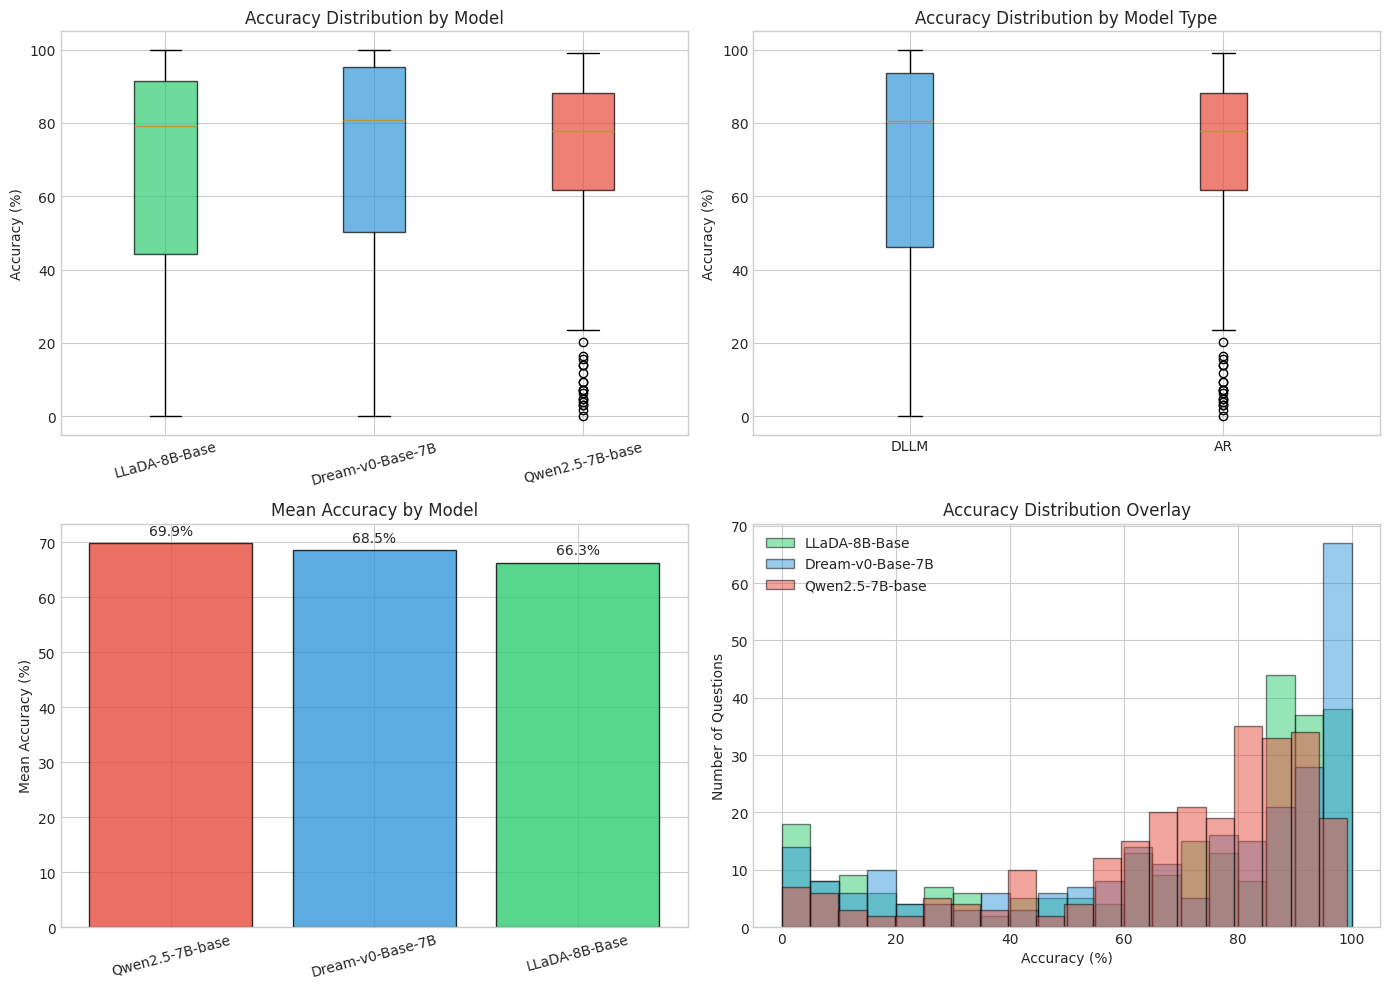

In [ ]:
# Color mapping
model_colors = {c['model']: c['color'] for c in MODEL_CONFIGS}
type_colors = {'DLLM': '#3498db', 'AR': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot by model
ax1 = axes[0, 0]
models = df['model'].unique()
box_data = [df[df['model'] == m]['accuracy'] for m in models]
bp = ax1.boxplot(box_data, labels=models, patch_artist=True)
for patch, model in zip(bp['boxes'], models):
    patch.set_facecolor(model_colors.get(model, 'gray'))
    patch.set_alpha(0.7)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Distribution by Model')
ax1.tick_params(axis='x', rotation=15)

# 2. Box plot by model type
ax2 = axes[0, 1]
types = df['model_type'].unique()
box_data_type = [df[df['model_type'] == t]['accuracy'] for t in types]
bp2 = ax2.boxplot(box_data_type, labels=types, patch_artist=True)
for patch, mtype in zip(bp2['boxes'], types):
    patch.set_facecolor(type_colors.get(mtype, 'gray'))
    patch.set_alpha(0.7)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Distribution by Model Type')

# 3. Bar chart - Mean accuracy by model
ax3 = axes[1, 0]
mean_acc = df.groupby('model')['accuracy'].mean().sort_values(ascending=False)
colors = [model_colors.get(m, 'gray') for m in mean_acc.index]
bars = ax3.bar(mean_acc.index, mean_acc.values, color=colors, edgecolor='black', alpha=0.8)
ax3.set_ylabel('Mean Accuracy (%)')
ax3.set_title('Mean Accuracy by Model')
ax3.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, mean_acc.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# 4. Histogram overlay
ax4 = axes[1, 1]
for model in models:
    model_data = df[df['model'] == model]['accuracy']
    ax4.hist(model_data, bins=20, alpha=0.5, label=model, 
             color=model_colors.get(model, 'gray'), edgecolor='black')
ax4.set_xlabel('Accuracy (%)')
ax4.set_ylabel('Number of Questions')
ax4.set_title('Accuracy Distribution Overlay')
ax4.legend()

plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Question Comparison Across Models

In [12]:
# Pivot table: accuracy per question for each model
pivot_accuracy = df.pivot_table(
    index=['question_idx', 'question', 'ground_truth'],
    columns='model',
    values='accuracy',
    aggfunc='first'
).reset_index()

print(f"Per-question comparison: {len(pivot_accuracy)} questions")
pivot_accuracy.sample(5)

Per-question comparison: 256 questions


model,question_idx,question,ground_truth,Dream-v0-Base-7B,LLaDA-8B-Base,Qwen2.5-7B-base
216,216,John buys 10 bottles of scotch for a total cost of $600. He also buys twice as many bottles of ...,2400.0,64.06250,68.75000,86.71875
163,163,John visits his parents twice a month. It takes him 2 hours to drive there at a speed of 70 mph...,560.0,16.40625,7.03125,67.96875
66,66,Marty has 100 centimeters of ribbon that he must cut into 4 equal parts. Each of the cut parts m...,5.0,95.31250,89.84375,78.90625
104,104,"Lindsay is doing the laundry, and thinks she has missed some socks. There are 50 socks that need...",15.0,99.21875,91.40625,89.06250
165,165,"Christina is planning a birthday party and needs .75 gift bags per invited guest, because 1/4 of...",24.0,96.09375,55.46875,3.90625


In [8]:
# Find questions where models differ most
model_cols = [c for c in pivot_accuracy.columns if c not in ['question_idx', 'question', 'ground_truth']]

if len(model_cols) >= 2:
    # Calculate variance across models for each question
    pivot_accuracy['variance'] = pivot_accuracy[model_cols].var(axis=1)
    pivot_accuracy['range'] = pivot_accuracy[model_cols].max(axis=1) - pivot_accuracy[model_cols].min(axis=1)
    
    print("\n" + "="*80)
    print("QUESTIONS WITH HIGHEST VARIANCE ACROSS MODELS")
    print("(Where models disagree the most)")
    print("="*80)
    
    high_var = pivot_accuracy.nlargest(10, 'variance')[['question_idx', 'question', 'ground_truth'] + model_cols + ['range']]
    for _, row in high_var.iterrows():
        print(f"\nQ{row['question_idx']}: {row['question'][:70]}...")
        print(f"   GT: {row['ground_truth']}")
        for m in model_cols:
            print(f"   {m}: {row[m]:.1f}%")


QUESTIONS WITH HIGHEST VARIANCE ACROSS MODELS
(Where models disagree the most)

Q182: Carrie is planning the caroling schedule. The choir plans to sing "Dec...
   GT: 540.0
   Dream-v0-Base-7B: 95.3%
   LLaDA-8B-Base: 11.7%
   Qwen2.5-7B-base: 91.4%

Q242: Imma has 3 cats. She feeds her cats twice a day with 60 grams of cat f...
   GT: 2.0
   Dream-v0-Base-7B: 93.8%
   LLaDA-8B-Base: 24.2%
   Qwen2.5-7B-base: 4.7%

Q165: Christina is planning a birthday party and needs .75 gift bags per inv...
   GT: 24.0
   Dream-v0-Base-7B: 96.1%
   LLaDA-8B-Base: 55.5%
   Qwen2.5-7B-base: 3.9%

Q178: The local firefighters are doing a “fill the boot” fundraiser. Their g...
   GT: 9.0
   Dream-v0-Base-7B: 82.0%
   LLaDA-8B-Base: 4.7%
   Qwen2.5-7B-base: 7.0%

Q57: If one person can paint half a house in 5 days, how many hours would i...
   GT: 48.0
   Dream-v0-Base-7B: 78.9%
   LLaDA-8B-Base: 7.0%
   Qwen2.5-7B-base: 86.7%

Q1: Janet goes to the mall and spends $3.50 on ice cream, $7.50 each for m..

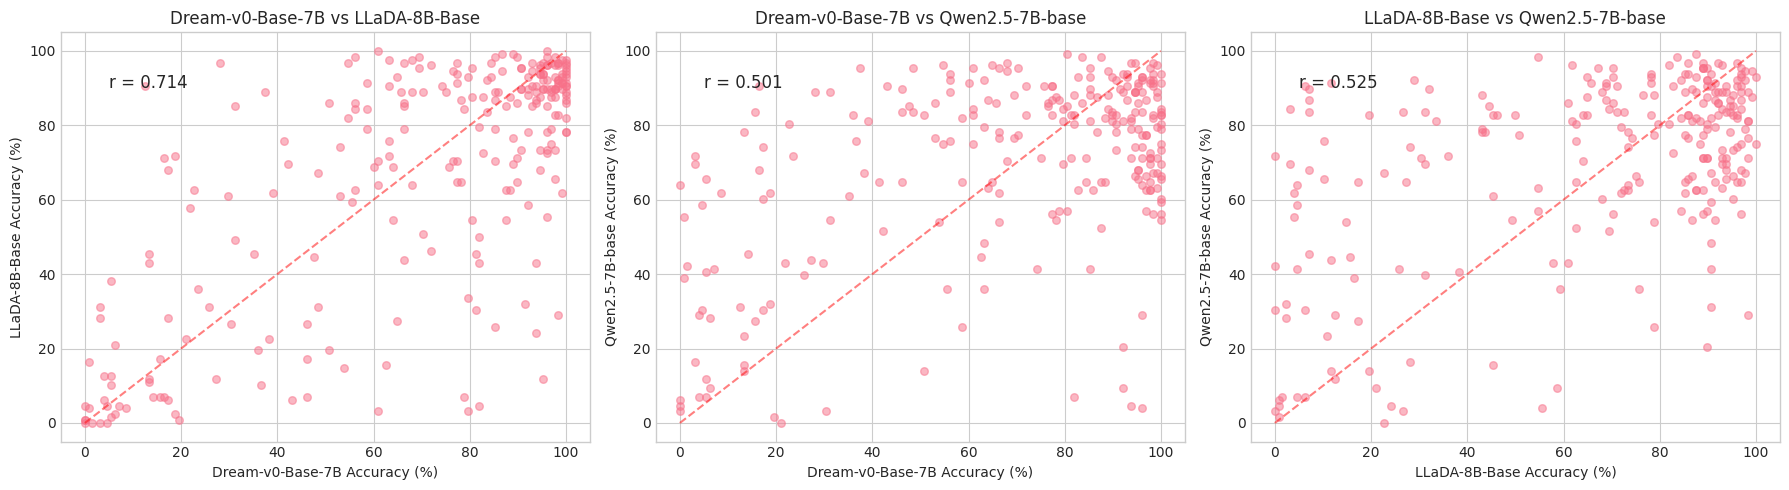

In [13]:
# Scatter plot comparing models pairwise
if len(model_cols) >= 2:
    from itertools import combinations
    pairs = list(combinations(model_cols, 2))
    
    n_pairs = len(pairs)
    fig, axes = plt.subplots(1, n_pairs, figsize=(6*n_pairs, 5))
    if n_pairs == 1:
        axes = [axes]
    
    for ax, (m1, m2) in zip(axes, pairs):
        ax.scatter(pivot_accuracy[m1], pivot_accuracy[m2], alpha=0.5, s=30)
        ax.plot([0, 100], [0, 100], 'r--', alpha=0.5, label='y=x')
        ax.set_xlabel(f'{m1} Accuracy (%)')
        ax.set_ylabel(f'{m2} Accuracy (%)')
        ax.set_title(f'{m1} vs {m2}')
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        
        # Calculate correlation
        corr = pivot_accuracy[m1].corr(pivot_accuracy[m2])
        ax.text(5, 90, f'r = {corr:.3f}', fontsize=12)
    
    plt.tight_layout()
    # plt.savefig('model_pairwise_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. DLLM vs AR Analysis

DLLM vs AR Per-Question Analysis

Questions where DLLM > AR: 123
Questions where AR > DLLM: 132
Questions with equal accuracy: 1

Average difference (DLLM - AR): -2.46%


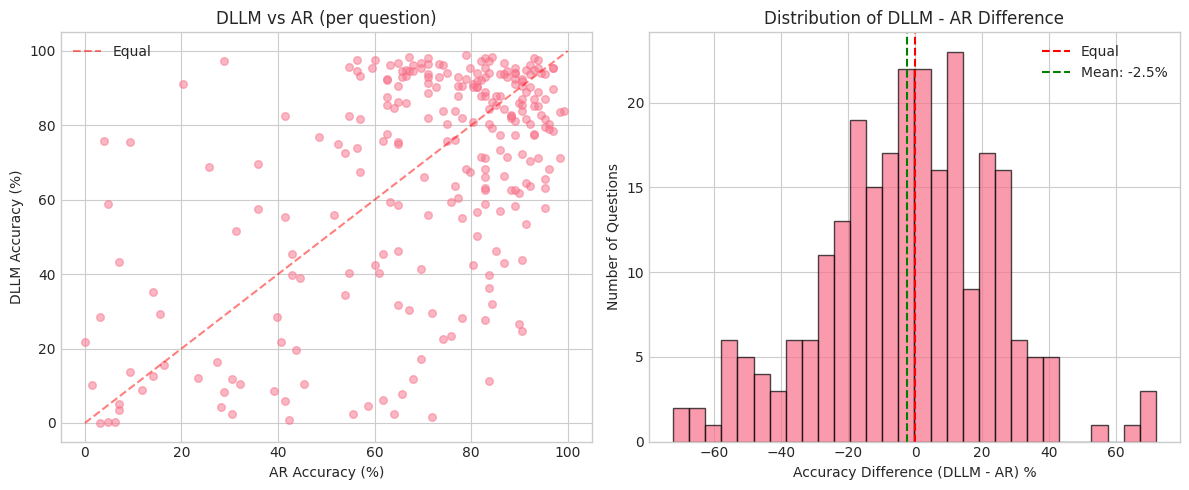

In [11]:
# Compare DLLM vs AR by aggregating
type_comparison = df.groupby(['question_idx', 'model_type'])['accuracy'].mean().unstack()

if 'DLLM' in type_comparison.columns and 'AR' in type_comparison.columns:
    print("DLLM vs AR Per-Question Analysis")
    print("="*60)
    
    type_comparison['diff'] = type_comparison['DLLM'] - type_comparison['AR']
    
    print(f"\nQuestions where DLLM > AR: {(type_comparison['diff'] > 0).sum()}")
    print(f"Questions where AR > DLLM: {(type_comparison['diff'] < 0).sum()}")
    print(f"Questions with equal accuracy: {(type_comparison['diff'] == 0).sum()}")
    print(f"\nAverage difference (DLLM - AR): {type_comparison['diff'].mean():.2f}%")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter
    ax1 = axes[0]
    ax1.scatter(type_comparison['AR'], type_comparison['DLLM'], alpha=0.5, s=30)
    ax1.plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Equal')
    ax1.set_xlabel('AR Accuracy (%)')
    ax1.set_ylabel('DLLM Accuracy (%)')
    ax1.set_title('DLLM vs AR (per question)')
    ax1.legend()
    
    # Difference histogram
    ax2 = axes[1]
    ax2.hist(type_comparison['diff'], bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(0, color='red', linestyle='--', label='Equal')
    ax2.axvline(type_comparison['diff'].mean(), color='green', linestyle='--', 
                label=f"Mean: {type_comparison['diff'].mean():.1f}%")
    ax2.set_xlabel('Accuracy Difference (DLLM - AR) %')
    ax2.set_ylabel('Number of Questions')
    ax2.set_title('Distribution of DLLM - AR Difference')
    ax2.legend()
    
    plt.tight_layout()
    # plt.savefig('dllm_vs_ar.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Pass@k by Model

In [15]:
# Use existing pass@k implementation from metrics/pass_k.py
# It expects list of dicts with 'total_samples' and 'correct_count' keys

def prepare_pass_at_k_input(model_df):
    """Convert DataFrame to format expected by compute_pass_at_k."""
    return [
        {
            'total_samples': row['num_generations'],
            'correct_count': row['correct_count']
        }
        for _, row in model_df.iterrows()
    ]

# Define k values to compute
k_values = [1, 2, 4, 8, 16, 32, 64, 128]

# Calculate pass@k for each model using existing implementation
pass_at_k_results = {}
for model_name, model_df in model_dfs.items():
    results_list = prepare_pass_at_k_input(model_df)
    # compute_pass_at_k returns dict {k: float} where float is in [0, 1]
    pass_k = compute_pass_at_k(results_list, k_values)
    # Convert to percentage
    pass_at_k_results[model_name] = {k: v * 100 for k, v in pass_k.items()}

# Create DataFrame
pass_at_k_df = pd.DataFrame(pass_at_k_results).T
pass_at_k_df.columns = [f'pass@{k}' for k in pass_at_k_df.columns]

print("Pass@k Metrics by Model:")
print("="*60)
pass_at_k_df.round(2)

Pass@k Metrics by Model:


,pass@1,pass@2,pass@4,pass@8,pass@16,pass@32,pass@64,pass@128
LLaDA-8B-Base,66.27,78.44,85.46,90.10,93.55,96.04,97.56,98.44
Dream-v0-Base-7B,68.51,80.11,87.13,91.54,94.58,96.63,97.83,98.44
Qwen2.5-7B-base,69.85,85.09,92.50,95.70,97.53,98.78,99.44,99.61


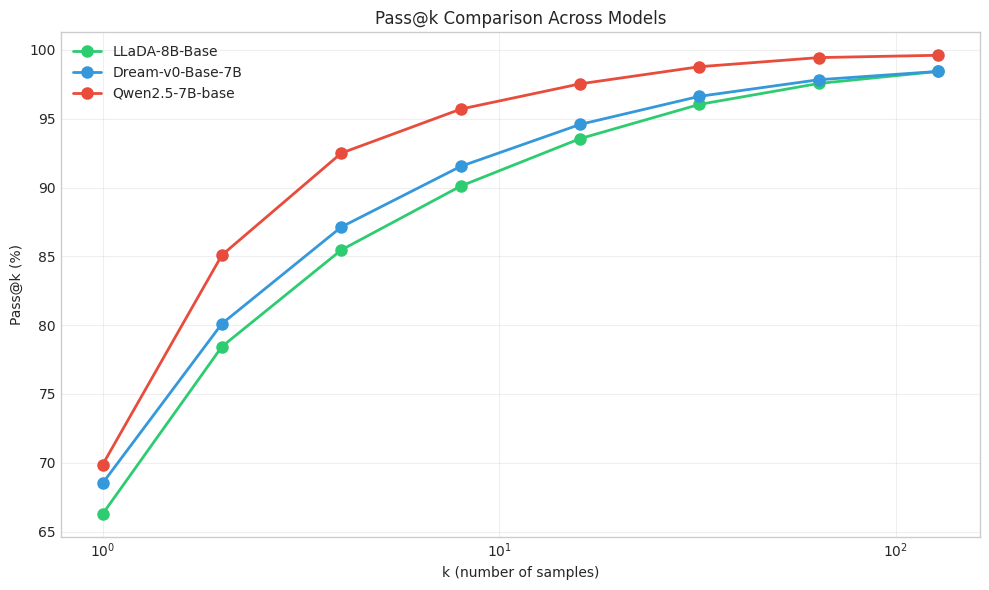

In [16]:
# Visualize pass@k
fig, ax = plt.subplots(figsize=(10, 6))

for model_name in pass_at_k_results:
    k_values = list(pass_at_k_results[model_name].keys())
    pass_values = list(pass_at_k_results[model_name].values())
    color = model_colors.get(model_name, 'gray')
    ax.plot(k_values, pass_values, marker='o', linewidth=2, markersize=8, 
            label=model_name, color=color)

ax.set_xlabel('k (number of samples)')
ax.set_ylabel('Pass@k (%)')
ax.set_title('Pass@k Comparison Across Models')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('pass_at_k_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Majority Voting Accuracy by Model

In [18]:
def calculate_majority_voting_accuracy(data):
    """Calculate accuracy using majority voting (all samples)."""
    correct = 0
    total = len(data['generations'])
    
    for item in data['generations']:
        ground_truth = item['ground_truth']
        answers = [a for a in item['extracted_answer'] if a is not None]
        
        if not answers:
            continue
        
        most_common = Counter(answers).most_common(1)[0][0]
        
        if isinstance(most_common, (int, float)) and isinstance(ground_truth, (int, float)):
            if abs(most_common - ground_truth) < 1e-6:
                correct += 1
        elif str(most_common) == str(ground_truth):
            correct += 1
    
    return correct / total * 100


def majority_vote_at_k(answers, ground_truth, k, n_trials=100):
    """
    Calculate majority voting accuracy at k samples.
    
    Args:
        answers: List of all extracted answers
        ground_truth: The correct answer
        k: Number of samples to use for majority voting
        n_trials: Number of random trials to average over
    
    Returns:
        Probability of correct majority vote with k samples
    """
    valid_answers = [a for a in answers if a is not None]
    n = len(valid_answers)
    
    if n == 0 or k > n:
        return 0.0
    
    correct_count = 0
    
    for _ in range(n_trials):
        # Sample k answers
        sampled = np.random.choice(valid_answers, size=min(k, n), replace=False)
        
        # Get majority vote
        counter = Counter(sampled)
        most_common = counter.most_common(1)[0][0]
        
        # Check correctness
        if isinstance(most_common, (int, float)) and isinstance(ground_truth, (int, float)):
            if abs(most_common - ground_truth) < 1e-6:
                correct_count += 1
        elif str(most_common) == str(ground_truth):
            correct_count += 1
    
    return correct_count / n_trials


def compute_majority_vote_at_k(data, k_values, n_trials=100):
    """Compute majority voting accuracy for multiple k values."""
    results = {k: [] for k in k_values}
    
    for item in data['generations']:
        ground_truth = item['ground_truth']
        answers = item['extracted_answer']
        
        for k in k_values:
            acc = majority_vote_at_k(answers, ground_truth, k, n_trials)
            results[k].append(acc)
    
    return {k: np.mean(v) * 100 for k, v in results.items()}


# Calculate majority voting (all samples) for each model
majority_results = {}
for config in MODEL_CONFIGS:
    if not Path(config['path']).exists():
        continue
    data = load_results(config['path'])
    majority_acc = calculate_majority_voting_accuracy(data)
    majority_results[config['model']] = majority_acc

print("Majority Voting Accuracy (all samples):")
print("="*40)
for model, acc in majority_results.items():
    print(f"  {model}: {acc:.2f}%")

Majority Voting Accuracy (all samples):
  LLaDA-8B-Base: 79.69%
  Dream-v0-Base-7B: 82.42%
  Qwen2.5-7B-base: 91.41%


### Majority Vote@k

Unlike `pass@k` which measures the probability of getting *at least one* correct answer in k samples, `maj@k` measures the probability that the *majority vote* of k samples gives the correct answer.

- **pass@k**: At least 1 of k samples is correct
- **maj@k**: The most common answer among k samples is correct

Majority voting is useful when we want a single final answer through consensus.

In [19]:
# Compute Majority Vote at k for different k values
k_values_maj = [1, 2, 4, 8, 16, 32, 64, 128]

print("Computing Majority Vote@k (this may take a minute)...")
print("="*60)

majority_at_k_results = {}
for config in MODEL_CONFIGS:
    if not Path(config['path']).exists():
        continue
    
    print(f"\n  Processing {config['model']}...")
    data = load_results(config['path'])
    
    np.random.seed(42)  # For reproducibility
    maj_at_k = compute_majority_vote_at_k(data, k_values_maj, n_trials=100)
    majority_at_k_results[config['model']] = maj_at_k
    
    for k, acc in sorted(maj_at_k.items()):
        print(f"    maj@{k}: {acc:.2f}%")

# Create DataFrame
maj_at_k_df = pd.DataFrame(majority_at_k_results).T
maj_at_k_df.columns = [f'maj@{k}' for k in maj_at_k_df.columns]

print("\n" + "="*60)
print("Majority Vote@k Results:")
print("="*60)
maj_at_k_df.round(2)

    maj@1: 66.53%
    maj@2: 66.34%
    maj@4: 75.17%
    maj@8: 78.29%
    maj@16: 79.54%
    maj@32: 80.07%
    maj@64: 79.82%
    maj@128: 79.69%

  Processing Dream-v0-Base-7B...
    maj@1: 68.43%
    maj@2: 68.35%
    maj@4: 76.89%
    maj@8: 80.14%
    maj@16: 81.32%
    maj@32: 82.11%
    maj@64: 82.44%
    maj@128: 82.41%

  Processing Qwen2.5-7B-base...
    maj@1: 69.57%
    maj@2: 69.84%
    maj@4: 84.11%
    maj@8: 89.21%
    maj@16: 90.67%
    maj@32: 91.05%
    maj@64: 91.12%
    maj@128: 91.41%

Majority Vote@k Results:


,maj@1,maj@2,maj@4,maj@8,maj@16,maj@32,maj@64,maj@128
LLaDA-8B-Base,66.53,66.34,75.17,78.29,79.54,80.07,79.82,79.69
Dream-v0-Base-7B,68.43,68.35,76.89,80.14,81.32,82.11,82.44,82.41
Qwen2.5-7B-base,69.57,69.84,84.11,89.21,90.67,91.05,91.12,91.41


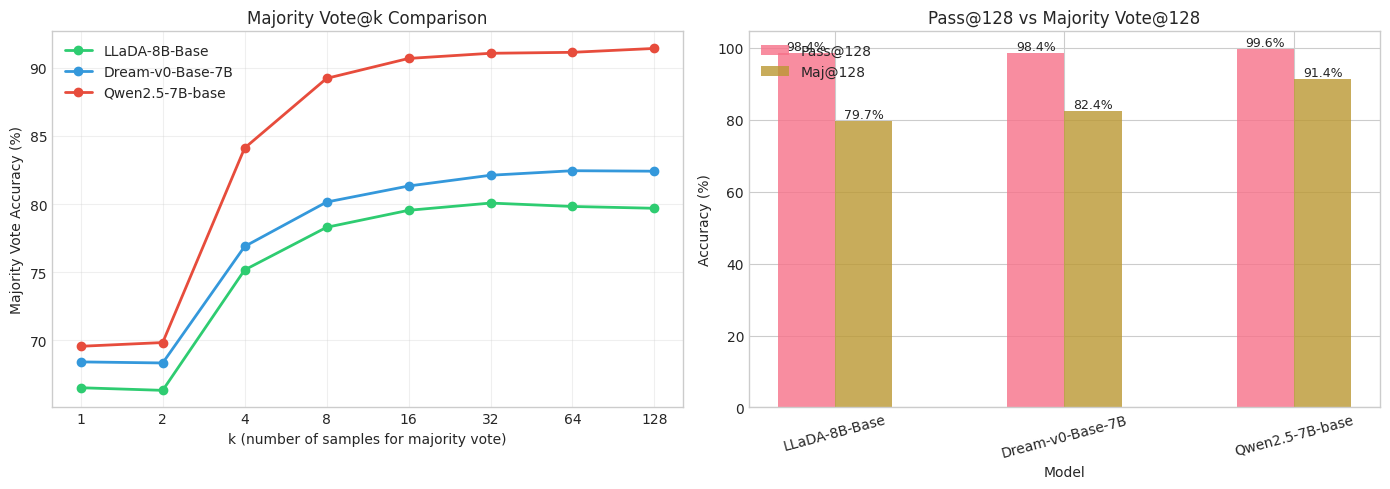

In [20]:
# Visualize Majority Vote@k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Majority Vote@k curves
ax1 = axes[0]
for model_name in majority_at_k_results:
    k_vals = list(majority_at_k_results[model_name].keys())
    maj_vals = list(majority_at_k_results[model_name].values())
    color = model_colors.get(model_name, 'gray')
    ax1.plot(k_vals, maj_vals, marker='o', linewidth=2, markersize=6, 
             label=model_name, color=color)

ax1.set_xlabel('k (number of samples for majority vote)')
ax1.set_ylabel('Majority Vote Accuracy (%)')
ax1.set_title('Majority Vote@k Comparison')
ax1.set_xscale('log', base=2)
ax1.set_xticks(k_values_maj)
ax1.set_xticklabels(k_values_maj)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Compare Pass@k vs Majority Vote@k for each model
ax2 = axes[1]
bar_width = 0.25
x = np.arange(len(model_dfs))
models_list = list(model_dfs.keys())

# Get pass@128 and maj@128 for comparison
pass_128 = [pass_at_k_results.get(m, {}).get(128, 0) for m in models_list]
maj_128 = [majority_at_k_results.get(m, {}).get(128, 0) for m in models_list]

bars1 = ax2.bar(x - bar_width/2, pass_128, bar_width, label='Pass@128', alpha=0.8)
bars2 = ax2.bar(x + bar_width/2, maj_128, bar_width, label='Maj@128', alpha=0.8)

ax2.set_xlabel('Model')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Pass@128 vs Majority Vote@128')
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=15)
ax2.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
             ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# plt.savefig('majority_vote_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Hardest and Easiest Questions by Model

In [38]:
# Hardest questions per model
print("="*80)
print("HARDEST QUESTIONS (0% accuracy) BY MODEL")
print("="*80)

for model_name in model_dfs:
    model_df = model_dfs[model_name]
    hardest = model_df[model_df['accuracy'] == 0]
    print(f"\n{model_name}: {len(hardest)} questions with 0% accuracy")
    
    if len(hardest) > 0:
        for _, row in hardest.head(3).iterrows():
            print(f"  Q{row['question_idx']}: {row['question'][:60]}... (GT: {row['ground_truth']})")

HARDEST QUESTIONS (0% accuracy) BY MODEL

LLaDA-8B-Base: 4 questions with 0% accuracy
  Q19: Brett is 14 years old. In four years his sister Angela will ... (GT: 38.0)
  Q59: Emily can peel 6 shrimp a minute and saute 30 shrimp in 10 m... (GT: 45.0)
  Q153: If Martin eats Cheerios every day for breakfast, he'll lose ... (GT: 15.0)

Dream-v0-Base-7B: 4 questions with 0% accuracy
  Q70: Every day Charisma meditates for 15 minutes when she first w... (GT: 34.0)
  Q166: Bill is signing up for a new streaming service. He got a spe... (GT: 284.0)
  Q202: Bubbles collects stuffed animals. She has three stuffed pupp... (GT: 6.0)

Qwen2.5-7B-base: 1 questions with 0% accuracy
  Q129: My wife wants to evenly split the check but wants me to pay ... (GT: 35.0)


In [39]:
# Questions that are hard for all models
if len(model_cols) >= 2:
    avg_accuracy = pivot_accuracy[model_cols].mean(axis=1)
    pivot_accuracy['avg_accuracy'] = avg_accuracy
    
    print("="*80)
    print("UNIVERSALLY HARD QUESTIONS (Low accuracy across ALL models)")
    print("="*80)
    
    hardest_all = pivot_accuracy.nsmallest(10, 'avg_accuracy')
    for _, row in hardest_all.iterrows():
        print(f"\nQ{row['question_idx']}: {row['question'][:70]}...")
        print(f"   GT: {row['ground_truth']} | Avg: {row['avg_accuracy']:.1f}%")
        for m in model_cols:
            print(f"   {m}: {row[m]:.1f}%")

UNIVERSALLY HARD QUESTIONS (Low accuracy across ALL models)

Q224: Jenny goes to the florist to buy some flowers. Roses cost $2 each and ...
   GT: 16.0 | Avg: 1.0%
   Dream-v0-Base-7B: 0.0%
   LLaDA-8B-Base: 0.0%
   Qwen2.5-7B-base: 3.1%

Q70: Every day Charisma meditates for 15 minutes when she first wakes up an...
   GT: 34.0 | Avg: 1.8%
   Dream-v0-Base-7B: 0.0%
   LLaDA-8B-Base: 0.8%
   Qwen2.5-7B-base: 4.7%

Q166: Bill is signing up for a new streaming service. He got a special intro...
   GT: 284.0 | Avg: 2.3%
   Dream-v0-Base-7B: 0.0%
   LLaDA-8B-Base: 0.8%
   Qwen2.5-7B-base: 6.2%

Q98: Blake and Kelly are having a contest to see who can run the most in 15...
   GT: 80.0 | Avg: 4.7%
   Dream-v0-Base-7B: 5.5%
   LLaDA-8B-Base: 1.6%
   Qwen2.5-7B-base: 7.0%

Q6: James needs to get more toys for his doggie shelter. Each dog needs on...
   GT: 33.0 | Avg: 5.7%
   Dream-v0-Base-7B: 3.9%
   LLaDA-8B-Base: 6.2%
   Qwen2.5-7B-base: 7.0%

Q230: Tim gets a promotion that offers him a 5%

## 10. Final Summary Table

In [ ]:
# Create comprehensive summary
summary_data = []

for config in MODEL_CONFIGS:
    model_name = config['model']
    if model_name not in model_dfs:
        continue
    
    mdf = model_dfs[model_name]
    
    row = {
        'Model': model_name,
        'Type': config['model_type'],
        'Questions': len(mdf),
        'Generations': mdf['num_generations'].iloc[0],
        'Mean Acc %': mdf['accuracy'].mean(),
        'Median Acc %': mdf['accuracy'].median(),
        'Std %': mdf['accuracy'].std(),
        'Majority Vote %': majority_results.get(model_name, 0),
        'Pass@1 %': pass_at_k_results.get(model_name, {}).get(1, 0),
        'Pass@10 %': pass_at_k_results.get(model_name, {}).get(10, 0),
        'Pass@128 %': pass_at_k_results.get(model_name, {}).get(128, 0),
        '100% Acc': (mdf['accuracy'] == 100).sum(),
        '0% Acc': (mdf['accuracy'] == 0).sum(),
    }
    summary_data.append(row)

final_summary = pd.DataFrame(summary_data).set_index('Model')

print("="*100)
print("FINAL SUMMARY: ALL MODELS")
print("="*100)
final_summary.round(2)

FINAL SUMMARY: ALL MODELS


,Type,Questions,Generations,Mean Acc %,Median Acc %,Std %,Majority Vote %,Pass@1 %,Pass@10 %,Pass@128 %,100% Acc,0% Acc
Model,,,,,,,,,,,,
LLaDA-8B-Base,DLLM,256,128,66.27,79.30,32.12,79.69,98.44,92.87,98.44,2,4
Dream-v0-Base-7B,DLLM,256,128,68.51,80.86,31.79,82.42,98.44,94.10,98.44,17,4
Qwen2.5-7B-base,AR,256,128,69.85,77.73,24.42,91.41,99.61,97.23,99.61,0,1


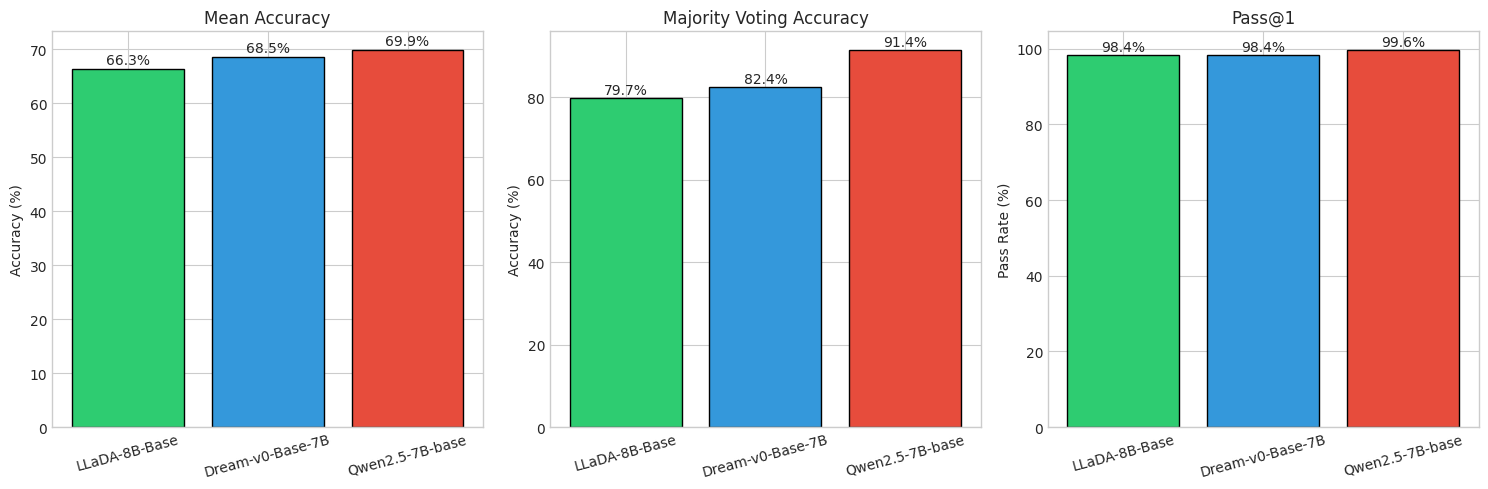

In [ ]:
# Final visualization - Summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = final_summary.index.tolist()
colors = [model_colors.get(m, 'gray') for m in models]

# Mean Accuracy
ax1 = axes[0]
bars1 = ax1.bar(models, final_summary['Mean Acc %'], color=colors, edgecolor='black')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Mean Accuracy')
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, final_summary['Mean Acc %']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')

# Majority Vote
ax2 = axes[1]
bars2 = ax2.bar(models, final_summary['Majority Vote %'], color=colors, edgecolor='black')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Majority Voting Accuracy')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, final_summary['Majority Vote %']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')

# Pass@1
ax3 = axes[2]
bars3 = ax3.bar(models, final_summary['Pass@1 %'], color=colors, edgecolor='black')
ax3.set_ylabel('Pass Rate (%)')
ax3.set_title('Pass@1')
ax3.tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, final_summary['Pass@1 %']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')

plt.tight_layout()
# plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()